In [1]:
Output = '/Users/alexis/Library/CloudStorage/OneDrive-UniversityofNorthCarolinaatChapelHill/CEMALB_DataAnalysisPM/Projects/P1015. Fire Sufficient Similarity/P1015.3. Analyses/P1015.3.3. Cluster Analysis/Output'
cur_date = '032426'

library(readxl)
library(tidyverse)
library(reshape2)
library(ComplexHeatmap)
library(data.table)

# reading in files
full_df = data.frame(read_excel("Input/Processed_Data_032426.xlsx")) %>%
    # removing records that weren't measured
    filter(Value2 == 'Present') %>%
    select(-Value2)
wf_info_df = data.frame(read_excel("Input/Study_Info_WF_012226.xlsx", sheet = 2))[,1:12]
ws_info_df = data.frame(read_excel("Input/Study_Info_WS_012226.xlsx", sheet = 2))[,1:15]
ws_info_df$HAWC_ID = as.character(ws_info_df$HAWC_ID)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths


Loading required package: grid

ComplexHeatmap version 2.24.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. C

In [2]:
head(full_df)
head(wf_info_df)
head(ws_info_df)

,HAWC_ID,Metric,Sample,Study,Sample_Number,Study_Sample_ID,DTXSID,Value,Class,Name
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
1,1289889,Volume,WF,Scaramboni et al. 2024,3,1289889_3,Ca,8.59618976,Metal,Calcium
2,1289889,Volume,WF,Scaramboni et al. 2024,3,1289889_3,Ni,0.54649640,Metal,Nickel
3,1289889,Volume,WF,Scaramboni et al. 2024,3,1289889_3,DTXSID2020139,0.12565110,PAH,Benzo(a)pyrene
4,1289889,Volume,WF,Scaramboni et al. 2024,3,1289889_3,DTXSID0022432,0.07997538,PAH,Chrysene
5,1289889,Volume,WF,Scaramboni et al. 2024,3,1289889_3,DTXSID8024153,0.10165008,PAH,"Indeno(1,2,3-cd)pyrene"
6,1289889,Volume,WF,Scaramboni et al. 2024,3,1289889_3,DTXSID3024104,0.15574923,PAH,Fluoranthene


,HAWC_ID,Study,Sample_Number,Study_Sample_ID,Class,Metric,Fire_Type,Location,PM_Size,Sample_Matrix,Fuel_Species,Fuel_Type
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1289737,Campbell et al. 2024,1,1289737_1,PAH,Weight,Natural,Wooded,NA,Ash,Eucalyptus,Hardwood
2,1289739,Campos et al. 2019,1,1289739_1,PAH,Weight,Natural,Wooded,NA,Ash,Eucalyptus,Hardwood
3,1289739,Campos et al. 2019,2,1289739_2,PAH,Weight,Natural,Wooded,NA,Ash,Eucalyptus,Hardwood
4,1289739,Campos et al. 2019,3,1289739_3,PAH,Weight,Natural,Wooded,NA,Ash,Eucalyptus,Hardwood
5,1289739,Campos et al. 2019,4,1289739_4,PAH,Weight,Natural,Wooded,NA,Ash,Eucalyptus,Hardwood
6,1289739,Campos et al. 2019,5,1289739_5,PAH,Weight,Natural,Wooded,NA,Ash,Pine,Softwood


,HAWC_ID,Study,Sample_Number,Study_Sample_ID,Class,Metric,Source,Combustion_Condition,PM_Size,Sample_Matrix,Fuel_Species,Sample_Origin,Fuel_Type,Efficiency,Fuel_Size
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,429174,Arif et al. 2017,1,429174_1,PAH,Weight,Boiler,NA,Very fine,PM,Mixed,Smoke,Softwood,Medium,Chip
2,429174,Arif et al. 2017,2,429174_2,PAH,Weight,Boiler,NA,Very fine,PM,Beech,Smoke,Hardwood,Medium,Chip
3,298566,Jalava et al. 2010,1,298566_1,PAH,Weight,Masonry heater,Normal,Very fine,PM,Birch,Flue gas,Hardwood,Medium,Log
4,298566,Jalava et al. 2010,2,298566_2,PAH,Weight,Masonry heater,Normal,Very fine,PM,Birch,Flue gas,Hardwood,Medium,Log
5,298566,Jalava et al. 2010,3,298566_3,PAH,Weight,Masonry heater,Smoldering,Very fine,PM,Birch,Flue gas,Hardwood,Medium,Log
6,298566,Jalava et al. 2010,4,298566_4,PAH,Weight,Masonry heater,Smoldering,Very fine,PM,Birch,Flue gas,Hardwood,Medium,Log


In [3]:
# creating 1 df that contains all the meta data
ws_info_df = ws_info_df %>%
    mutate(Sample = 'WS', Fire_Type = NA, Location = NA)
wf_info_df = wf_info_df %>%
    mutate(Sample = 'WF', Source = NA, Combustion_Condition = NA, Sample_Origin = NA, Efficiency = NA, Fuel_Size = NA) 
wf_info_df = wf_info_df[,colnames(ws_info_df)]

info_df = rbind(wf_info_df, ws_info_df)
head(info_df)

,HAWC_ID,Study,Sample_Number,Study_Sample_ID,Class,Metric,Source,Combustion_Condition,PM_Size,Sample_Matrix,Fuel_Species,Sample_Origin,Fuel_Type,Efficiency,Fuel_Size,Sample,Fire_Type,Location
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1289737,Campbell et al. 2024,1,1289737_1,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
2,1289739,Campos et al. 2019,1,1289739_1,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
3,1289739,Campos et al. 2019,2,1289739_2,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
4,1289739,Campos et al. 2019,3,1289739_3,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
5,1289739,Campos et al. 2019,4,1289739_4,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
6,1289739,Campos et al. 2019,5,1289739_5,PAH,Weight,NA,NA,NA,Ash,Pine,NA,Softwood,NA,NA,WF,Natural,Wooded


In [4]:
# splitting based on metric
metric_split = full_df %>%
    group_by(Metric) %>%
    group_split()

vol_df = metric_split[[1]]
weight_df = metric_split[[2]]

In [5]:
# converting to a wide format
wider_vol_df = vol_df %>%
    select(-c("DTXSID", "Class")) %>%
    # removing outliers
    #filter(SampleID %notin% vol_outliers) %>%
    pivot_wider(names_from = Name, values_from = Value) %>%
    column_to_rownames(var = "Study_Sample_ID")

wider_weight_df = weight_df %>%
    select(-c("DTXSID", "Class")) %>%
    pivot_wider(names_from = Name, values_from = Value) %>%
    column_to_rownames(var = "Study_Sample_ID")

head(wider_vol_df)

,HAWC_ID,Metric,Sample,Study,Sample_Number,Calcium,Nickel,Benzo(a)pyrene,Chrysene,"Indeno(1,2,3-cd)pyrene",⋯,Phenanthrene,Copper,Lead,Benzo(GHI)perylene,Iron,Potassium,Manganese,Pyrene,Strontium,Zinc
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1289889_3,1289889,Volume,WF,Scaramboni et al. 2024,3,8.596190,0.5464964,0.1256511,0.07997538,0.10165008,⋯,0.0772430,6.781360,0.8718436,0.214124805,7.247928,9.491853,1.448901,0.1123665,NA,NA
1289889_1,1289889,Volume,WF,Scaramboni et al. 2024,1,2.931926,0.6959938,0.9568001,0.40925515,1.00647756,⋯,0.2116353,6.221104,2.9164766,1.572404647,9.609179,9.612868,3.666757,0.5300707,NA,NA
1289889_2,1289889,Volume,WF,Scaramboni et al. 2024,2,2.931926,0.2986583,0.5607150,0.30451104,0.49159659,⋯,0.1137005,4.887525,2.0426443,1.261229909,8.629357,9.459432,2.558268,0.3459640,NA,NA
1426391_1,1426391,Volume,WF,O'Malley et al. 2024,1,NA,NA,0.1953476,0.64800518,0.04474382,⋯,5.1043367,NA,NA,0.073408955,NA,NA,NA,3.0959244,NA,NA
1426391_2,1426391,Volume,WF,O'Malley et al. 2024,2,NA,NA,0.4419814,0.08224829,0.01876099,⋯,2.0391384,NA,NA,0.002032767,NA,NA,NA,0.5048746,NA,NA
1426391_3,1426391,Volume,WF,O'Malley et al. 2024,3,NA,NA,0.4419814,0.01409816,0.01876099,⋯,1.7268312,NA,NA,0.001026833,NA,NA,NA,0.2326608,NA,NA


In [6]:
#analytes = colnames(wider_vol_df)[6:ncol(wider_vol_df)]

# scaling each col, but keeping the NAs as NAs
scale_column <- function(x) {
    avg <- mean(x, na.rm = TRUE)
    sdv <- stats::sd(x, na.rm = TRUE)

    # If constant or all NA, return zeros where not NA (keeps NA where NA)
    if (is.na(sdv) || sdv == 0) {
        out <- ifelse(is.na(x), NA, 0)
    } else {
        out <- (x - avg) / sdv
  }
  return(out)
}
vol_mat_scaled = apply(as.matrix(wider_vol_df[6:ncol(wider_vol_df)]), 2, scale_column)
weight_mat_scaled = apply(as.matrix(wider_weight_df[6:ncol(wider_weight_df)]), 2, scale_column)

head(vol_mat_scaled)

,Calcium,Nickel,Benzo(a)pyrene,Chrysene,"Indeno(1,2,3-cd)pyrene",Fluoranthene,Phenanthrene,Copper,Lead,Benzo(GHI)perylene,Iron,Potassium,Manganese,Pyrene,Strontium,Zinc
1289889_3,-1.459639,-1.842839,-0.5765558,-0.5634027,-0.3645709,-0.5477155,-0.61936632,-0.3512802,-1.967267,-0.4667317,-1.902409,-1.931819,-2.350044,-0.5479620,NA,NA
1289889_1,-2.705319,-1.791570,-0.4567095,-0.5168284,-0.1422210,-0.4982955,-0.60311977,-0.5665714,-1.295941,-0.2485227,-1.083761,-1.896873,-1.822390,-0.4936474,NA,NA
1289889_2,-2.705319,-1.927833,-0.5138224,-0.5316437,-0.2687464,-0.5287905,-0.61495901,-1.0790294,-1.582851,-0.2985133,-1.423466,-1.941181,-2.086112,-0.5175871,NA,NA
1426391_1,NA,NA,-0.5665060,-0.4830589,-0.3785548,-0.2827991,-0.01164601,NA,NA,-0.4893379,NA,NA,NA,-0.1600062,NA,NA
1426391_2,NA,NA,-0.5309430,-0.5630812,-0.3849398,-0.5158221,-0.38219475,NA,NA,-0.5008045,NA,NA,NA,-0.4969237,NA,NA
1426391_3,NA,NA,-0.5309430,-0.5727206,-0.3849398,-0.5317120,-0.41994925,NA,NA,-0.5009661,NA,NA,NA,-0.5323200,NA,NA


In [7]:
cluster_analyte_order = function (scaled_matrix){
    
    ## ---- Identify clusterable analytes ----
    non_na_counts <- colSums(!is.na(scaled_matrix))
    col_sds <- apply(scaled_matrix, 2, function(x) stats::sd(x, na.rm = TRUE))
    good_cols <- which(non_na_counts >= 2 & !is.na(col_sds) & col_sds > 0)
    bad_cols  <- setdiff(seq_len(ncol(scaled_matrix)), good_cols)
    
    ## ---- Cluster good analytes using Spearman correlation ----
    clustered_good <- character(0)
    if (length(good_cols) >= 2) {
      col_cor <- suppressWarnings(cor(
        scaled_matrix[, good_cols, drop = FALSE],
        use = "pairwise.complete.obs",
        method = "spearman"
      ))
      # Replace NAs (e.g., non-overlapping pairs), set diagonal to 1, enforce symmetry
      col_cor[is.na(col_cor)] <- 0
      diag(col_cor) <- 1
      col_cor <- (col_cor + t(col_cor)) / 2
    
      # Convert to a proper square distance matrix WITHOUT pmax()
      col_dist_mat <- 1 - col_cor
      col_dist_mat[col_dist_mat < 0] <- 0  # clamp tiny negatives due to numerical noise
      diag(col_dist_mat) <- 0
    
      # Sanity checks to avoid your previous error
      stopifnot(is.matrix(col_dist_mat))
      stopifnot(nrow(col_dist_mat) == ncol(col_dist_mat))
    
      # Build a 'dist' and cluster
      col_dist <- as.dist(col_dist_mat)
      col_hc <- hclust(col_dist, method = "average")
      clustered_good <- colnames(scaled_matrix)[good_cols][col_hc$order]
    
    } else if (length(good_cols) == 1) {
      clustered_good <- colnames(scaled_matrix)[good_cols]
    }
    
    ## ---- Final column order: clustered good analytes, then bad ones ----
    final_order <- c(clustered_good, colnames(scaled_matrix)[bad_cols])

    return(final_order)
}

# calling fn
vol_final_order = cluster_analyte_order(vol_mat_scaled)
weight_final_order = cluster_analyte_order(weight_mat_scaled)

In [8]:
# reordering the column names based on the cluster order
final_vol_matrix = vol_mat_scaled[,vol_final_order]
final_weight_matrix = weight_mat_scaled[,weight_final_order]

In [9]:
# wider_weight_df %>%
#     select(Sample) %>%
#     rownames_to_column(var = "Study_Sample_ID") %>%
#     left_join(info_df[,c(4,6,9:11,13,16:18)]) %>%
#     filter(Study_Sample_ID %in% c('1289922_1', '981013_2')) %>%
#     filter(Study_Sample_ID == '1289922_1' & Location == 'Wooded' |
#            Study_Sample_ID == '981013_2' & PM_Size == 'Very fine')
#     # select(-Metric) %>%
#     # unique() %>%
#     # remove_rownames()

In [10]:
head(info_df)

,HAWC_ID,Study,Sample_Number,Study_Sample_ID,Class,Metric,Source,Combustion_Condition,PM_Size,Sample_Matrix,Fuel_Species,Sample_Origin,Fuel_Type,Efficiency,Fuel_Size,Sample,Fire_Type,Location
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1289737,Campbell et al. 2024,1,1289737_1,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
2,1289739,Campos et al. 2019,1,1289739_1,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
3,1289739,Campos et al. 2019,2,1289739_2,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
4,1289739,Campos et al. 2019,3,1289739_3,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
5,1289739,Campos et al. 2019,4,1289739_4,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
6,1289739,Campos et al. 2019,5,1289739_5,PAH,Weight,NA,NA,NA,Ash,Pine,NA,Softwood,NA,NA,WF,Natural,Wooded


In [9]:
# reordering the cols to match the cluster order
ordered_vol_matrix = vol_mat_scaled[,vol_final_order]
ordered_weight_matrix = weight_mat_scaled[,weight_final_order]
head(ordered_vol_matrix)

# creating the dataframes that contain the additional metadata
annotation_vol_col_df = wider_vol_df %>%
    select(Sample) %>%
    rownames_to_column(var = "Study_Sample_ID") %>%
    left_join(info_df[,c(4,6,9:11,13,16:18)]) %>%
    select(-Metric) %>%
    unique() %>%
    remove_rownames() %>%
    column_to_rownames(var = "Study_Sample_ID") %>%
    mutate(Sample = ifelse(Sample == "WS", "Woodsmoke",
                                  ifelse(Sample == "WF", "Wildfire", Sample))) 
# removing some ids that were causing issues..
removed_id_df = info_df %>%
    filter(Study_Sample_ID == '1289922_1' & Location == 'Wooded' |
    Study_Sample_ID == '981013_2' & PM_Size == 'Very fine')

info_df2 = anti_join(info_df, removed_id_df)
annotation_weight_col_df = wider_weight_df %>%
    select(Sample) %>%
    rownames_to_column(var = "Study_Sample_ID") %>%
    left_join(info_df2[,c(4,6,9:10,13,16:18)]) %>%
    select(-Metric) %>%
    unique() %>%
    remove_rownames() %>%
    column_to_rownames(var = "Study_Sample_ID") %>%
    mutate(Sample = ifelse(Sample == "WS", "Woodsmoke",
                                  ifelse(Sample == "WF", "Wildfire", Sample))) 
  
annotation_vol_row_df = unique(vol_df[,c("Class", "Name")]) %>%
    column_to_rownames(var = "Name")
annotation_weight_row_df = unique(weight_df[,c("Class", "Name")]) %>%
    column_to_rownames(var = "Name")

# rearranging row names so that they're in the same order
annotation_vol_row_df = annotation_vol_row_df[vol_final_order,, drop = FALSE]
annotation_weight_row_df = annotation_weight_row_df[weight_final_order,, drop = FALSE]

head(annotation_vol_col_df)
head(annotation_vol_row_df)

,Iron,"Indeno(1,2,3-cd)pyrene",Strontium,Calcium,Manganese,Phenanthrene,Fluoranthene,Pyrene,Chrysene,Lead,Nickel,Copper,Potassium,Benzo(a)pyrene,Benzo(GHI)perylene,Zinc
1289889_3,-1.902409,-0.3645709,NA,-1.459639,-2.350044,-0.61936632,-0.5477155,-0.5479620,-0.5634027,-1.967267,-1.842839,-0.3512802,-1.931819,-0.5765558,-0.4667317,NA
1289889_1,-1.083761,-0.1422210,NA,-2.705319,-1.822390,-0.60311977,-0.4982955,-0.4936474,-0.5168284,-1.295941,-1.791570,-0.5665714,-1.896873,-0.4567095,-0.2485227,NA
1289889_2,-1.423466,-0.2687464,NA,-2.705319,-2.086112,-0.61495901,-0.5287905,-0.5175871,-0.5316437,-1.582851,-1.927833,-1.0790294,-1.941181,-0.5138224,-0.2985133,NA
1426391_1,NA,-0.3785548,NA,NA,NA,-0.01164601,-0.2827991,-0.1600062,-0.4830589,NA,NA,NA,NA,-0.5665060,-0.4893379,NA
1426391_2,NA,-0.3849398,NA,NA,NA,-0.38219475,-0.5158221,-0.4969237,-0.5630812,NA,NA,NA,NA,-0.5309430,-0.5008045,NA
1426391_3,NA,-0.3849398,NA,NA,NA,-0.41994925,-0.5317120,-0.5323200,-0.5727206,NA,NA,NA,NA,-0.5309430,-0.5009661,NA


Joining with `by = join_by(Study_Sample_ID, Sample)`
Joining with `by = join_by(HAWC_ID, Study, Sample_Number, Study_Sample_ID,
Class, Metric, Source, Combustion_Condition, PM_Size, Sample_Matrix,
Fuel_Species, Sample_Origin, Fuel_Type, Efficiency, Fuel_Size, Sample,
Fire_Type, Location)`
Joining with `by = join_by(Study_Sample_ID, Sample)`


,Sample,PM_Size,Sample_Matrix,Fuel_Species,Fuel_Type,Fire_Type,Location
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1289889_3,Wildfire,Fine,Air,NA,NA,Natural,Urban and wooded
1289889_1,Wildfire,Fine,Air,NA,NA,Natural,Urban and wooded
1289889_2,Wildfire,Fine,Air,NA,NA,Natural,Urban and wooded
1426391_1,Wildfire,Fine,Air,NA,NA,Natural,Urban and wooded
1426391_2,Wildfire,Fine,Air,NA,NA,Natural,Urban and wooded
1426391_3,Wildfire,Fine,Air,NA,NA,Natural,Urban and wooded


,Class
,<chr>
Iron,Metal
"Indeno(1,2,3-cd)pyrene",PAH
Strontium,Metal
Calcium,Metal
Manganese,Metal
Phenanthrene,PAH


In [12]:
# obtaining color palette
fall_colors = rev(palette(hcl.colors(10, "PiYG")))

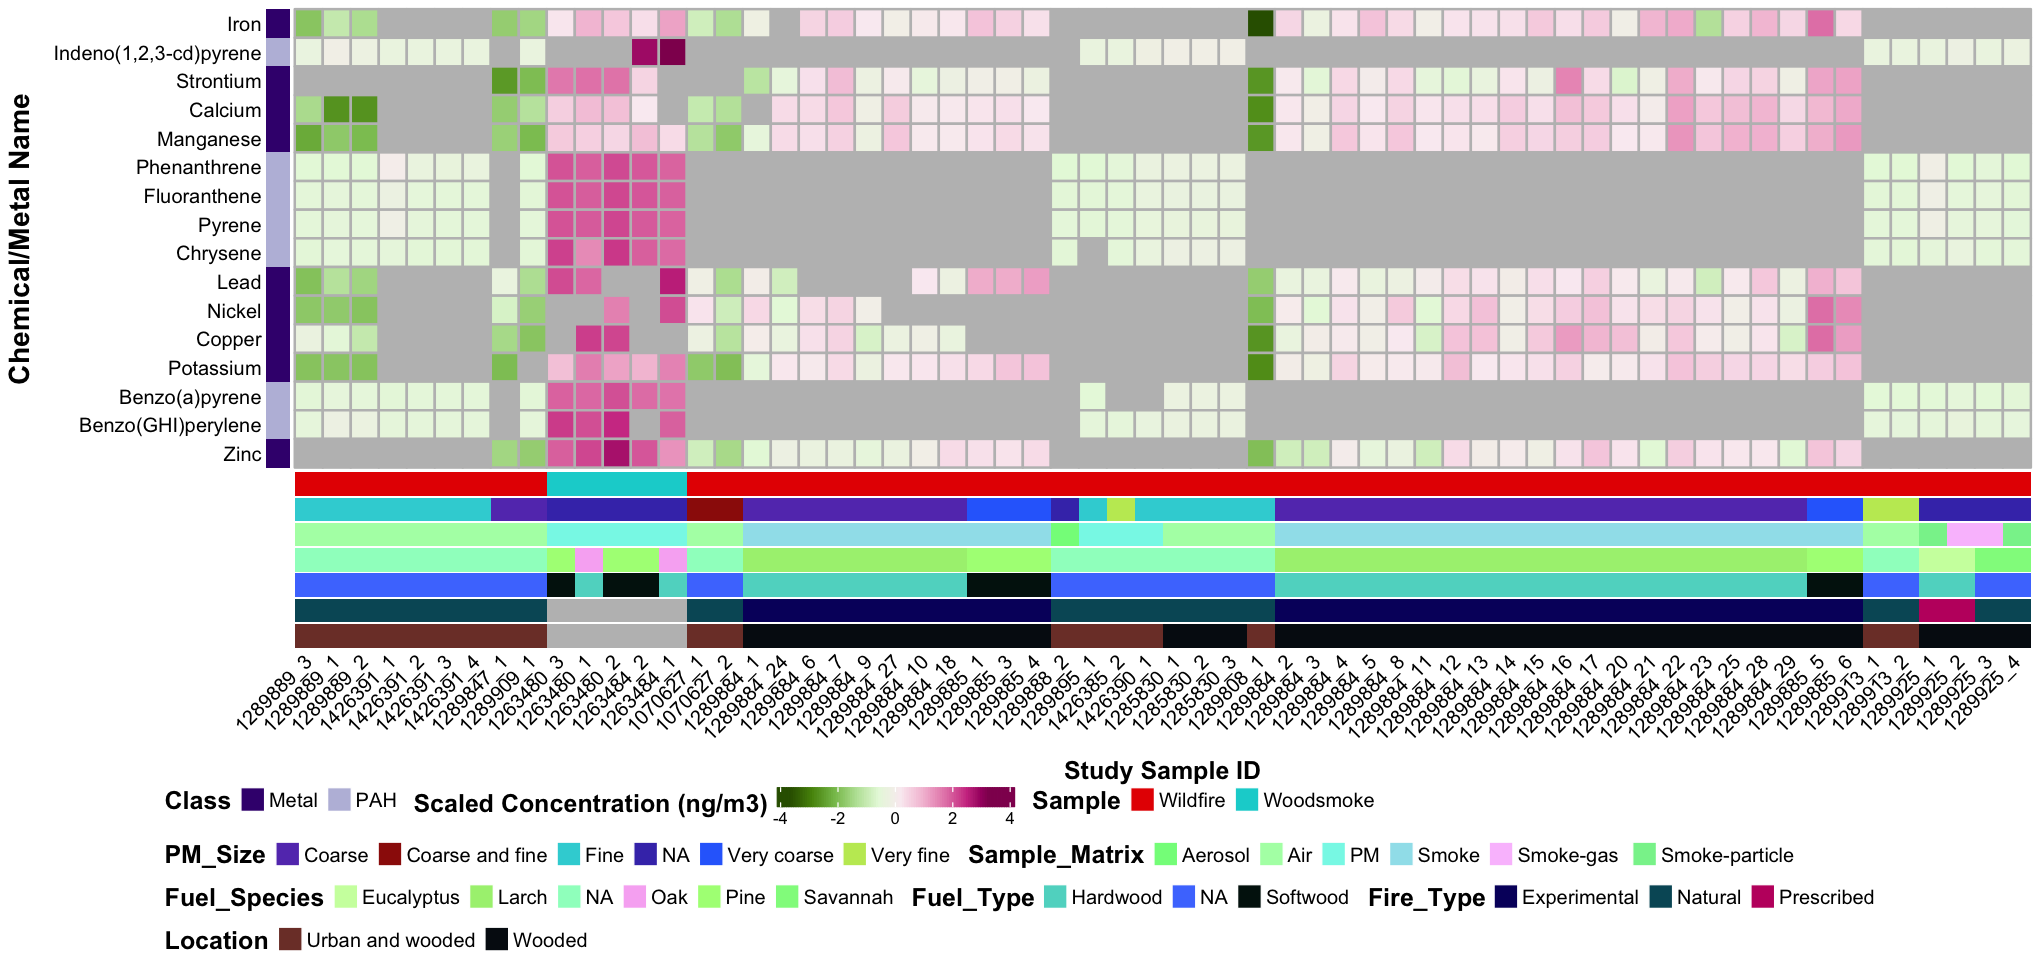

In [15]:
options(repr.plot.width=17, repr.plot.height=8) #changing size
vol_heatmap = Heatmap(t(final_vol_matrix), rect_gp = gpar(col = "gray", lwd = 2), # cell border color
     cluster_rows = FALSE,  cluster_columns = FALSE, 
     col = fall_colors, # changing colors

    # legend title
    heatmap_legend_param = list(title = gt_render("Scaled\nConcentration\n(ng/m3)"), 
              title_position = "leftcenter", direction = "horizontal", legend_width = unit(5, "cm"), 
              title_gp = gpar(fontsize = 15, fontface = "bold")),
   # adding axes titles
    column_title = "Study Sample ID", column_title_side = "bottom", 
    column_title_gp = gpar(fontsize = 15, fontface = "bold"),
    column_names_gp = gpar(fontsize = 12), column_names_rot = 45,
    row_title = "Chemical/Metal Name", row_title_rot = 90, 
    row_title_gp = gpar(fontsize = 17, fontface = "bold"),
    row_names_side = 'left', row_names_gp = gpar(fontsize = 12),
    
    # adding in annotation (additional data)
    bottom_annotation = HeatmapAnnotation(df = annotation_vol_col_df, show_annotation_name = FALSE,
    col = list(Sample = c(Wildfire = "#e60000", Woodsmoke = "#00d2d2")),  
    annotation_legend_param = list(title_position = "leftcenter", 
                                   grid_width = unit(0.5, "cm"), grid_height = unit(0.5, "cm"),
                                   title_gp = gpar(fontsize = 15, fontface = "bold"), nrow = 1,
                                   labels_gp = gpar(fontsize = 12))), 
             
    left_annotation = rowAnnotation(df = annotation_vol_row_df, show_annotation_name = FALSE,
                col = list(Class = c(Metal = "#3f007d", PAH = "#bcbddc", VOC = "#9E4200")), 
                annotation_legend_param = list(title_position = "leftcenter", 
                                               grid_width = unit(0.5, "cm"), grid_height = unit(0.5, "cm"),
                                               title_gp = gpar(fontsize = 15, fontface = "bold"), nrow = 1,
                                                labels_gp = gpar(fontsize = 12))) 
)

draw(vol_heatmap, merge_legend = TRUE, heatmap_legend_side = "bottom", 
    annotation_legend_side = "bottom")

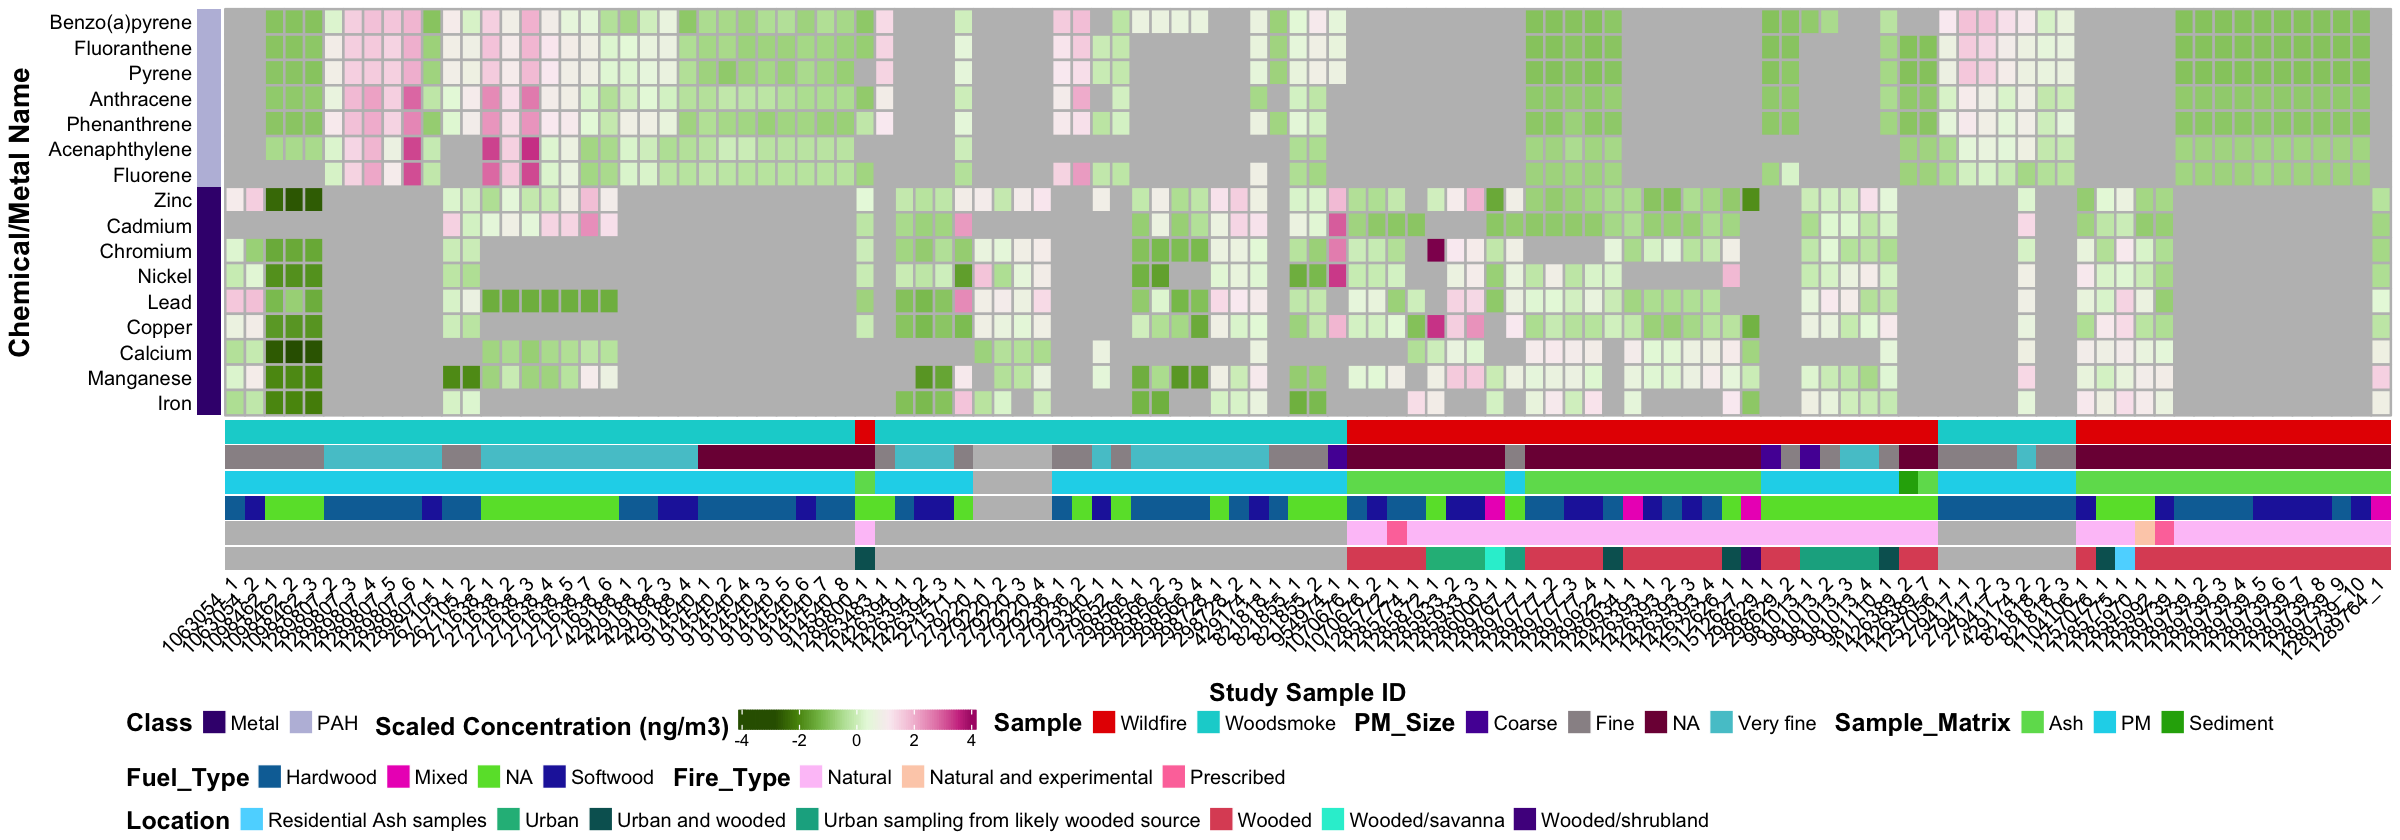

In [16]:
options(repr.plot.width=20, repr.plot.height=7) #changing size
weight_heatmap = Heatmap(t(final_weight_matrix), rect_gp = gpar(col = "gray", lwd = 2), # cell border color
     cluster_rows = FALSE,  cluster_columns = FALSE, 
     col = fall_colors, # changing colors
    #row_split = 2,

    # legend title
    heatmap_legend_param = list(title = gt_render("Scaled\nConcentration\n(ng/m3)"), 
              title_position = "leftcenter", direction = "horizontal", legend_width = unit(5, "cm"), 
              title_gp = gpar(fontsize = 15, fontface = "bold")),
   # adding axes titles
    column_title = "Study Sample ID", column_title_side = "bottom", 
    column_title_gp = gpar(fontsize = 15, fontface = "bold"),
    column_names_gp = gpar(fontsize = 12), column_names_rot = 45,
    row_title = "Chemical/Metal Name", row_title_rot = 90, 
    row_title_gp = gpar(fontsize = 17, fontface = "bold"),
    row_names_side = 'left', row_names_gp = gpar(fontsize = 12),
    
    # adding in annotation (additional data)
    bottom_annotation = HeatmapAnnotation(df = annotation_weight_col_df, show_annotation_name = FALSE,
    col = list(Sample = c(Wildfire = "#e60000", Woodsmoke = "#00d2d2")),  
    annotation_legend_param = list(title_position = "leftcenter", 
                                   grid_width = unit(0.5, "cm"), grid_height = unit(0.5, "cm"),
                                   title_gp = gpar(fontsize = 15, fontface = "bold"), nrow = 1,
                                   labels_gp = gpar(fontsize = 12))), 
             
    left_annotation = rowAnnotation(df = annotation_weight_row_df, show_annotation_name = FALSE,
                col = list(Class = c(Metal = "#3f007d", PAH = "#bcbddc", VOC = "#9E4200")), 
                annotation_legend_param = list(title_position = "leftcenter", 
                                               grid_width = unit(0.5, "cm"), grid_height = unit(0.5, "cm"),
                                               title_gp = gpar(fontsize = 15, fontface = "bold"), nrow = 1,
                                                labels_gp = gpar(fontsize = 12)))
)

draw(weight_heatmap, merge_legend = TRUE, heatmap_legend_side = "bottom", 
    annotation_legend_side = "bottom")